In [1]:
import optuna

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

pd.options.display.precision = 4
pd.options.mode.chained_assignment = None

if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

import tensorflow as tf
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.layers import Flatten, Dense, Dropout
# Machine learning pipeline
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import set_config
set_config(display="diagram")

In [3]:
df = pd.read_csv("data/laptop_data_cleaned.csv")

In [4]:
df

,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,Apple,Ultrabook,8,1.37,11.1758,0,1,226.9830,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,10.7768,0,0,127.6779,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,10.3299,0,0,141.2120,Intel Core i5,0,256,Intel,Others
3,Apple,Ultrabook,16,1.83,11.8145,0,1,220.5346,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,11.4731,0,1,226.9830,Intel Core i5,0,256,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1268,Asus,Notebook,4,2.20,10.5553,0,0,100.4547,Intel Core i7,500,0,Nvidia,Windows
1269,Lenovo,2 in 1 Convertible,4,1.80,10.4339,1,1,157.3505,Intel Core i7,0,128,Intel,Windows
1270,Lenovo,2 in 1 Convertible,16,1.30,11.2881,1,1,276.0535,Intel Core i7,0,512,Intel,Windows
1271,Lenovo,Notebook,2,1.50,9.4093,0,0,111.9352,Other Intel Processor,0,0,Intel,Windows


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1273 non-null   object 
 1   TypeName     1273 non-null   object 
 2   Ram          1273 non-null   int64  
 3   Weight       1273 non-null   float64
 4   Price        1273 non-null   float64
 5   TouchScreen  1273 non-null   int64  
 6   Ips          1273 non-null   int64  
 7   Ppi          1273 non-null   float64
 8   Cpu_brand    1273 non-null   object 
 9   HDD          1273 non-null   int64  
 10  SSD          1273 non-null   int64  
 11  Gpu_brand    1273 non-null   object 
 12  Os           1273 non-null   object 
dtypes: float64(3), int64(5), object(5)
memory usage: 129.4+ KB


In [6]:
df.isnull().sum()

Company        0
TypeName       0
Ram            0
Weight         0
Price          0
TouchScreen    0
Ips            0
Ppi            0
Cpu_brand      0
HDD            0
SSD            0
Gpu_brand      0
Os             0
dtype: int64

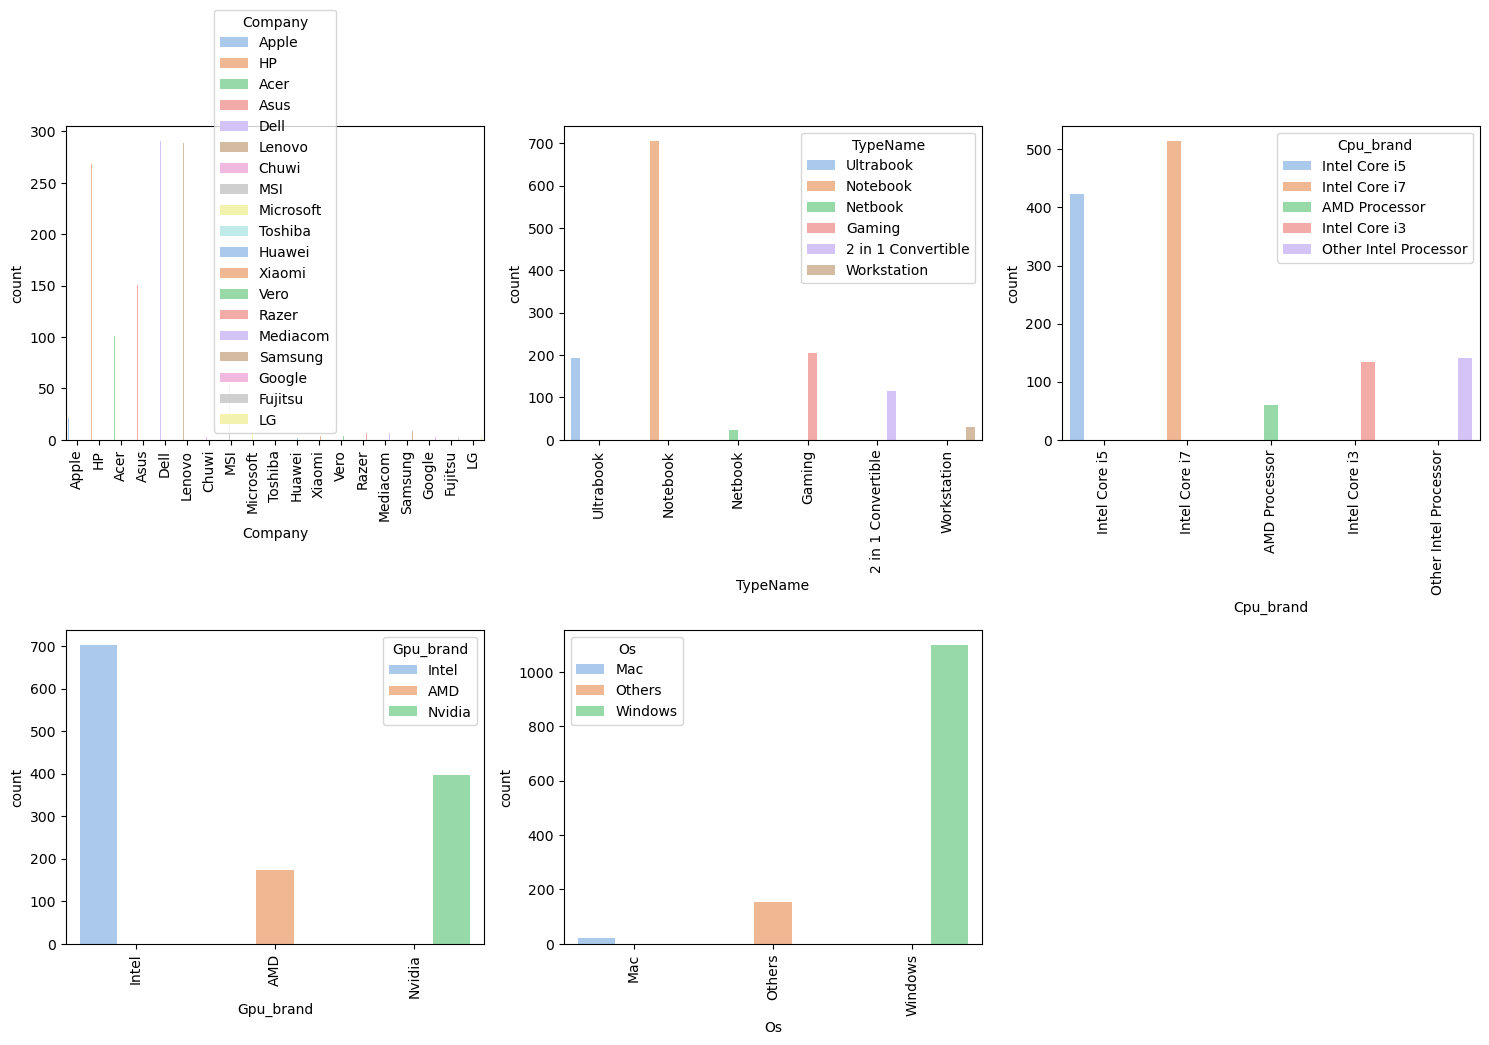

In [7]:
categories = df[['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'Os']]

plt.figure(figsize = (15, 10))
for i, col in enumerate(categories.columns, 1):
  plt.subplot(2, 3, i)
  sns.countplot(x=categories[col], hue=categories[col], palette='pastel')
  plt.tight_layout()
  plt.xticks(rotation=90)
plt.show()

In [8]:
features = df.columns.drop('Price')
NUMERICAL = df[features].select_dtypes('number').columns
CATEGORICAL = df[features].select_dtypes('object').columns

In [9]:
X = df.drop(['Price'], axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1018, 12) (255, 12) (1018,) (255,)


In [17]:
class Scaler(BaseEstimator, TransformerMixin):
    def __init__(self, features):
        self.features = features

    def fit(self, X, y=None):
        self.min = X[self.features].min()
        self.range = X[self.features].max()-self.min
        return self

    def transform(self, X):
        X_transformed = X.copy()
        X_transformed[self.features] = (X[self.features]-self.min)/self.range
        return X_transformed


class Encoder(BaseEstimator, TransformerMixin):
    def __init__(self, features, drop='first'):
        self.features = features
        self.drop = drop

    def fit(self, X, y=None):
        self.encoder = OneHotEncoder(drop=self.drop)
        self.encoder.fit(X[self.features])
        return self

    def transform(self, X):
        X_transformed = pd.concat([X.drop(columns=self.features).reset_index(drop=True),
                                   pd.DataFrame(self.encoder.transform(X[self.features]),
                                                columns=self.encoder.get_feature_names_out(self.features))],
                                  axis=1)
        return X_transformed


class NeuralNetworkTrainer(BaseEstimator, TransformerMixin):
    def __init__(self, epochs=50, learning_rate=0.01, units1=32, units2=32, droupout_rate=0, verbose=0):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.units1 = units1
        self.units2 = units2
        self.droupout_rate = droupout_rate
        self.verbose = verbose
        self.model = None

    def fit(self, X, y=None):
        input_shape = (X.shape[1],)  # Форма входных данных на основе X

        model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(units=self.units1, activation='relu', input_shape=input_shape),
            tf.keras.layers.Dropout(rate=self.droupout_rate),
            tf.keras.layers.Dense(units=self.units2, activation='relu'),
            tf.keras.layers.Dense(units=1)
        ])

        optimizer = Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer,
                      loss='mse',
                      metrics=['mae'])

        model.fit(X, y, epochs=self.epochs, verbose=self.verbose)
        self.model = model
        return self

    def transform(self, X):
        # NeuralNetworkTrainer не изменяет данные, поэтому просто возвращаем X
        return X

    def predict(self, X):
        # Предсказать метки классов для новых данных X
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        return y_pred

    def score(self, X, y=None):
        # Оцените производительность модели на данных X и y
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        mae = mean_absolute_error(y, y_pred)
        return mae

In [18]:
# Optuna параметры для нейронной сети
def objective(trial):
  param = {
      'epochs': trial.suggest_categorical('epochs', [100, 200, 300, 400, 500]),
      'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 1e-1),
      'units1': trial.suggest_categorical('units1', [256, 512, 1024, 2048, 4096, 8192]),
      'units2': trial.suggest_categorical('units2', [128, 256, 512, 1024, 2048, 4096, 8192]),
      'droupout_rate': trial.suggest_categorical('droupout_rate', [0, 0.01, 0.03, 0.05, 0.1, 0.15]),
      'verbose': trial.suggest_categorical('verbose', [0])
  }

  neural_network = NeuralNetworkTrainer(**param)
  # конвейер с нейронной сетью
  pipeline = Pipeline([
      ('scaler', Scaler(NUMERICAL)),
      ('encoder', Encoder(CATEGORICAL)),
      ('neural_network', neural_network)
  ])

  pipeline.fit(X_train, y_train)
  val_mae = pipeline.score(X_train, y_train)

  return val_mae

In [19]:
X_train

,Company,TypeName,Ram,Weight,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
647,Razer,Gaming,16,1.95,0,0,157.3505,Intel Core i7,0,256,Nvidia,Windows
370,Asus,2 in 1 Convertible,12,2.26,1,0,141.2120,Intel Core i7,2000,512,Nvidia,Windows
894,MSI,Gaming,16,2.43,0,1,254.6713,Intel Core i7,2000,512,Nvidia,Windows
381,Lenovo,Notebook,4,1.85,0,0,141.2120,Intel Core i3,0,128,Intel,Others
467,Dell,Notebook,8,2.02,0,0,141.2120,Intel Core i5,2000,0,AMD,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...
733,Acer,Notebook,4,2.40,0,0,100.4547,Intel Core i5,500,0,Intel,Windows
1180,Lenovo,2 in 1 Convertible,8,1.36,1,1,209.8007,Intel Core i5,0,256,Intel,Windows
1147,Dell,Notebook,8,2.18,0,0,141.2120,Intel Core i7,0,256,Nvidia,Windows
527,Lenovo,Notebook,8,2.20,0,0,100.4547,Intel Core i3,2000,0,Nvidia,Others


In [20]:
study = optuna.create_study(direction='minimize')  # 'maximize' for accuracy, 'minimize' for loss
study.optimize(objective, n_trials=500)

[I 2024-07-07 17:12:16,263] A new study created in memory with name: no-name-d4f47745-1f27-4df0-b957-34da3cdd2d2a
[W 2024-07-07 17:12:16,297] Trial 0 failed with parameters: {'epochs': 300, 'learning_rate': 0.013873512575915221, 'units1': 4096, 'units2': 2048, 'droupout_rate': 0.15, 'verbose': 0} because of the following error: ValueError('Shape of passed values is (1018, 1), indices imply (1018, 31)').
Traceback (most recent call last):
  File "C:\Users\vboro\.conda\envs\py310\lib\site-packages\optuna\study\_optimize.py", line 196, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\vboro\AppData\Local\Temp\ipykernel_8828\762986687.py", line 20, in objective
    pipeline.fit(X_train, y_train)
  File "C:\Users\vboro\.conda\envs\py310\lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\vboro\.conda\envs\py310\lib\site-packages\sklearn\pipeline.py", line 471, in fit
    Xt = self._fit(X, y, routed_param

ValueError: Shape of passed values is (1018, 1), indices imply (1018, 31)

<h1> ? <h1>

In [21]:
df = pd.read_csv("data/CarPrice_Assignment.csv")

In [22]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [23]:
df['carwlh'] = df.carwidth + df.carlength + df.carheight
df = df.drop(['carwidth', 'carlength', 'carheight', 'CarName', 'car_ID', 'citympg', 'highwaympg'], axis=1)

In [24]:
df['drivewheel'] = df['drivewheel'].replace("4wd", 'wdf')
df['fuelsystem'] = df['fuelsystem'].replace("2bbl", 'tbbi')
df['fuelsystem'] = df['fuelsystem'].replace("1bbl", 'obbl')
df['fuelsystem'] = df['fuelsystem'].replace("4bbl", 'fbbl')

df_dummie = pd.get_dummies(df, columns = ['aspiration', 'carbody', 'drivewheel', 'enginetype', 'cylindernumber', 'fuelsystem'])

In [25]:
categories_new  = ['doornumber', 'enginelocation',
       'boreratio', 'stroke', 'compressionratio',
       'carbody_hardtop', 'carbody_hatchback', 'carbody_sedan',
       'carbody_wagon', 'drivewheel_rwd', 'drivewheel_wdf', 'enginetype_dohcv',
       'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv',
       'enginetype_rotor', 'cylindernumber_five', 'cylindernumber_four',
       'cylindernumber_six', 'cylindernumber_three', 'cylindernumber_twelve',
       'cylindernumber_two','fuelsystem_idi', 'fuelsystem_mfi',
       'fuelsystem_mpfi', 'fuelsystem_obbl', 'fuelsystem_spdi',
       'fuelsystem_spfi', 'fuelsystem_tbbi','fueltype','fuelsystem_fbbl','cylindernumber_eight',
       'enginetype_dohc','drivewheel_fwd','carbody_convertible','aspiration_turbo','aspiration_std']

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for feature in categories_new:
    df_dummie[feature] = le.fit_transform(df_dummie[feature])

In [26]:
X = df_dummie.drop(['price'], axis = 1)
y = df_dummie['price']

X_train, X_test, y_train, y_test =  train_test_split(X, y, train_size=0.80, random_state=42)

In [27]:
mmc = MinMaxScaler()

X_train = mmc.fit_transform(X_train)
X_test = mmc.transform(X_test)

In [28]:
from sklearn.ensemble import RandomForestRegressor

In [29]:
class RandomForestRegressorTrainer(BaseEstimator, TransformerMixin):
    def __init__(self, n_estimators=1000, max_depth=8):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.model = None

    def fit(self, X, y=None):
        self.model = RandomForestRegressor(n_estimators=self.n_estimators, max_depth=self.max_depth)
        self.model.fit(X, y)
        return self

    def transform(self, X):
        return X

    def predict(self, X):
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        return y_pred

    def score(self, X, y=None):
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        mae = mean_absolute_error(y, y_pred)
        return mae


params = {
    "n_estimators": 1200,
    "max_depth": 9
}

forest = RandomForestRegressorTrainer(**params)

pipe = Pipeline([
    ('model', forest)
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('model',
                 RandomForestRegressorTrainer(max_depth=9, n_estimators=1200))])

In [30]:
y_pred = pipe.predict(X_test)

In [31]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE =", mae)

MAE = 1294.3896776416977


In [32]:
rf = RandomForestRegressor(n_estimators=1200, max_depth=9)
rf.fit(X_train, y_train)

print('MAE =', mean_absolute_error(y_test, rf.predict(X_test)))

MAE = 1253.6503055328947


In [33]:
class Scaler(BaseEstimator, TransformerMixin):
    def __init__(self, features):
        self.features = features

    def fit(self, X, y=None):
        self.min = X[self.features].min()
        self.range = X[self.features].max()-self.min
        return self

    def transform(self, X):
        X_transformed = X.copy()
        X_transformed[self.features] = (X[self.features]-self.min)/self.range
        return X_transformed


class Encoder(BaseEstimator, TransformerMixin):
    def __init__(self, features, drop='first'):
        self.features = features
        self.drop = drop

    def fit(self, X, y=None):
        self.encoder = OneHotEncoder(sparse_output=False, drop=self.drop)
        self.encoder.fit(X[self.features])
        return self

    def transform(self, X):
        X_transformed = pd.concat([X.drop(columns=self.features).reset_index(drop=True),
                                   pd.DataFrame(self.encoder.transform(X[self.features]),
                                                columns=self.encoder.get_feature_names_out(self.features))],
                                  axis=1)
        return X_transformed


class NeuralNetworkTrainer(BaseEstimator, TransformerMixin):
    def __init__(self, epochs=50, learning_rate=0.01, units1=32, units2=32, units3=32, droupout_rate=0, verbose=0):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.units1 = units1
        self.units2 = units2
        self.units3 = units3        
        self.droupout_rate = droupout_rate
        self.verbose = verbose
        self.model = None

    def fit(self, X, y=None):
        input_shape = (X.shape[1],)  # Форма входных данных на основе X

        model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(units=self.units1, activation='relu', input_shape=input_shape),
            tf.keras.layers.Dense(units=self.units2, activation='relu'),
            Dropout(rate=self.droupout_rate),
            tf.keras.layers.Dense(units=self.units3, activation='relu'),
            tf.keras.layers.Dense(units=1)
        ])

        optimizer = Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer,
                      loss='mse',
                      metrics=['mae'])

        model.fit(X, y, epochs=self.epochs, verbose=self.verbose)
        self.model = model
        return self

    def transform(self, X):
        # NeuralNetworkTrainer не изменяет данные, поэтому просто возвращаем X
        return X

    def predict(self, X):
        # Предсказать метки классов для новых данных X
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        return y_pred

    def score(self, X, y=None):
        # Оцените производительность модели на данных X и y
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        mae = mean_absolute_error(y, y_pred)
        return mae

In [34]:
# Optuna параметры для нейронной сети
def objective(trial):
  param = {
      'epochs': trial.suggest_categorical('epochs', [100, 200, 300, 400, 500]),
      'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 1e-1),
      'units1': trial.suggest_categorical('units1', [256, 512, 1024, 2048, 4096, 8192]),
      'units2': trial.suggest_categorical('units2', [128, 256, 512, 1024, 2048, 4096, 8192]),
      'units3': trial.suggest_categorical('units2', [128, 256, 512, 1024, 2048, 4096, 8192]),
      'droupout_rate': trial.suggest_categorical('droupout_rate', [0, 0.01, 0.03, 0.05, 0.1, 0.15]),
      'verbose': trial.suggest_categorical('verbose', [0])
  }

  neural_network = NeuralNetworkTrainer(**param)
  # конвейер с нейронной сетью
  pipeline = Pipeline([
      ('neural_network', neural_network)
  ])

  pipeline.fit(X_train, y_train)
  val_mae = pipeline.score(X_train, y_train)

  return val_mae

In [35]:
study = optuna.create_study(direction='minimize')  # 'maximize' for accuracy, 'minimize' for loss
study.optimize(objective, n_trials=15)

[I 2024-07-07 17:16:13,916] A new study created in memory with name: no-name-fcd0886c-8f8c-4f25-9866-d38097a0921c


6/6 [==============================] - 0s 32ms/step


[I 2024-07-07 17:23:50,887] Trial 0 finished with value: 1036.4496415301066 and parameters: {'epochs': 400, 'learning_rate': 0.07206186356287733, 'units1': 1024, 'units2': 8192, 'droupout_rate': 0.1, 'verbose': 0}. Best is trial 0 with value: 1036.4496415301066.


6/6 [==============================] - 0s 1ms/step


[I 2024-07-07 17:23:54,239] Trial 1 finished with value: 3988.968023532774 and parameters: {'epochs': 300, 'learning_rate': 5.4069156976675135e-05, 'units1': 1024, 'units2': 128, 'droupout_rate': 0.01, 'verbose': 0}. Best is trial 0 with value: 1036.4496415301066.


...

6/6 [==============================] - 0s 1ms/step


[I 2024-07-07 17:24:16,876] Trial 3 finished with value: 1110.9616490806022 and parameters: {'epochs': 500, 'learning_rate': 0.00032516799865358784, 'units1': 256, 'units2': 512, 'droupout_rate': 0.03, 'verbose': 0}. Best is trial 0 with value: 1036.4496415301066.


6/6 [==============================] - 0s 1ms/step


[I 2024-07-07 17:24:24,326] Trial 4 finished with value: 3153.8463611137577 and parameters: {'epochs': 400, 'learning_rate': 2.2787394416906132e-05, 'units1': 2048, 'units2': 512, 'droupout_rate': 0.03, 'verbose': 0}. Best is trial 0 with value: 1036.4496415301066.
[W 2024-07-07 17:32:03,088] Trial 5 failed with parameters: {'epochs': 500, 'learning_rate': 0.0012056457717252904, 'units1': 1024, 'units2': 8192, 'droupout_rate': 0.05, 'verbose': 0} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\vboro\.conda\envs\py310\lib\site-packages\optuna\study\_optimize.py", line 196, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\vboro\AppData\Local\Temp\ipykernel_8828\3241967213.py", line 19, in objective
    pipeline.fit(X_train, y_train)
  File "C:\Users\vboro\.conda\envs\py310\lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\vboro\.conda\envs\py

KeyboardInterrupt: 